# Homework 1

**Notes On Readings**

The original study by Aungle & Langer (2023) is structured in which participants got standardized cupping induced bruises and were told 3 different “false” amounts of time had elapsed during healing observations: in half time, normal time, or double time. Blind raters judged the bruises to have healed significantly more in the condition where participants believed more time had passed. The authors framed this as evidence for the concept of “mind-body unity,” where subjective time perception affects recovery, irrespective of actual elapsed time.

Gelman & Brown are skeptical because the model let each person have their own starting point for healing but forced everyone to have the same treatment effect. The effect of the time manipulation probably differs from person to person, but the model treated it as a fixed change applied identically to everyone. Another issue they raised is that the literature used to support the argument was unreplicated, methodologically shaky, or simply mischaracterized.

For a remedy, they suggest comparing the final results to simpler analyses, moving away from shot-in-the-dark studies with no clear mechanism, and examining previously published claims more carefully.

Terms I haven't seen yet: multilevel model, t statistic, garden of forking paths, manipulation check.

In [ ]:
## Uncomment to install packages (can sub with pip if not using conda)
## %conda install numpy matplotlib pandas 
## %conda install pandas

## Import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Question 1: Garden of Forking Paths

Given the question, suppose there are $N$ different reasonable ways to analyze a dataset. The hypothesis $H$ is actually true, but each analysis has probability $q$ (Type I error rate) of incorrectly rejecting $H$.

### Part (a)

Assuming the $N$ outcomes are independent, what is the probability that at least one analysis incorrectly rejects $H$?

Either at least one analysis rejects or none do, so $P(\text{at least one rejects}) = 1 - P(\text{none reject})$

Each analysis fails to reject with probability $1 - q$, and since the outcomes are independent, the probabilities multiply ($P(x,y) = P(x)P(y)$):

$$P(\text{none reject}) = (1-q)^N$$

Therefore:

$$\boxed{P(\text{at least one rejects}) = 1 - (1-q)^N}$$

### Part (b)

With $q = 0.05$, find $N$ such that $P(\text{at least one rejects}) \geq 0.5$:

$$1 - (0.95)^N = 0.5 \implies (0.95)^N = 0.5 \implies N = \frac{\log 0.5}{\log 0.95} \approx 13.51$$

So $N = 14$ analyses are enough to give a 50% chance of at least one false rejection.

The plot below shows the formula from part (a). You can see the curve crosses the 50% line between $N = 13$ and $N = 14$.

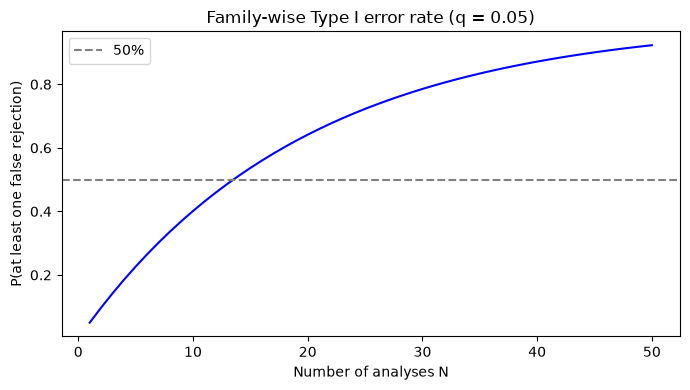

In [22]:
q = 0.05
N_vals = np.arange(1, 51)
prob = 1 - (1 - q) ** N_vals # closed form from part (a) for N = 1..50

plt.figure(figsize=(7, 4))
plt.plot(N_vals, prob, color="blue")
plt.axhline(0.5, color="gray", linestyle="--", label="50%") # where the curve crosses = answer to (b)
plt.xlabel("Number of analyses N")
plt.ylabel("P(at least one false rejection)")
plt.title(f"Family-wise Type I error rate (q = {q})")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
q = 0.05
rng = np.random.default_rng(42) # seeded so the results are reproducible
trials = 100_000

# smallest N where the part (a) formula reaches 50%
N = 1
while 1 - (1 - q) ** N < 0.5:
    N += 1
print(f"Smallest N with P(at least one rejects) >= 0.5: {N}")

for N_check in [N - 1, N]: # 14 should be the first N to reach 50%
    analytical = 1 - (1 - q) ** N_check
    # M = number of false rejections among N independent analyses ~ Binomial(N, q)
    M = rng.binomial(n=N_check, p=q, size=trials)
    sim_prob = np.mean(M >= 1) # fraction of trials with at least one rejection
    print(f"N={N_check}: analytical {analytical:.4f}, simulated {sim_prob:.4f}")

Smallest N with P(at least one rejects) >= 0.5: 14
N=13: analytical 0.4867, simulated 0.4883
N=14: analytical 0.5123, simulated 0.5098


### Part (c)

Analyses of one dataset are positively correlated. Let $p = \text{corr}(X_i, X_j)$, where $X_i = 1$ if analysis $i$ falsely rejects, so $X_i \sim \text{Bernoulli}(q)$.

Model: with probability $p$ all $N$ analyses copy one shared outcome, otherwise each is independent.

$$E[X_iX_j] = pq + (1-p)q^2$$

$$\text{cov}(X_i,X_j) = pq + (1-p)q^2 - q^2 = p\,q(1-q)$$

$$\text{corr}(X_i,X_j) = \frac{p\,q(1-q)}{q(1-q)} = p$$

Conditioning on whether the analyses agree:

$$P(\text{at least one rejects}) = pq + (1-p)\bigl(1-(1-q)^N\bigr)$$

$$p = 0:\ 1-(1-q)^N $$
$$p = 1:\ q$$

So correlation lowers the probability, between $q$ and $1-(1-q)^N$, but doesn't remove it. Negative $p$ could raise it above the independent case, so I only simulate $p \geq 0$.

In [24]:
rng = np.random.default_rng(42)
q = 0.05
N = 14
trials = 100_000
probs_reject = [1 - q, q] # P(no reject), P(reject) for one analysis

print(f"{'p':>5}  {'simulated':>10}  {'formula':>8}  {'sample corr':>12}")
print("-" * 41)
for p in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]: # p = correlation = prob. the analyses agree
    # 1 = analyses agree this trial (prob p), 0 = independent
    agree = rng.choice([0, 1], p=[1 - p, p], size=trials)
    shared = rng.choice([0, 1], p=probs_reject, size=(trials, 1)) # one outcome copied to all N
    X = rng.choice([0, 1], p=probs_reject, size=(trials, N)) # each analysis's own outcome
    X[agree == 1] = shared[agree == 1] # agreeing trials use the shared outcome

    sim = np.mean(np.sum(X, axis=1) >= 1) # at least one of N rejects
    formula = p * q + (1 - p) * (1 - (1 - q) ** N) # conditioning on agree / not agree
    C = np.cov(X[:, 0], X[:, 1]) # analyses 1 and 2 (any pair works)
    corr = C[0, 1] / C[0, 0] # cov/var; equal variances, so this is p
    print(f"{p:>5.1f}  {sim:>10.4f}  {formula:>8.4f}  {corr:>12.3f}")

    p   simulated   formula   sample corr
-----------------------------------------
  0.0      0.5124    0.5123         0.004
  0.3      0.3732    0.3736         0.299
  0.5      0.2854    0.2812         0.507
  0.7      0.1886    0.1887         0.706
  0.9      0.0954    0.0962         0.890
  1.0      0.0492    0.0500         1.000


## Question 2: Exploring the real healing data

In [25]:
## Loading data with code given

url = (
"https://media.springernature.com/original/springer-static/esm/"
"art%3A10.1038%2Fs41598-023-50009-3/MediaObjects/"
"41598_2023_50009_MOESM4_ESM.csv"
)
df = pd.read_csv(url)
df["S"] = pd.factorize(df["Subject"])[0] + 1 # subject id, 1-33
df["R"] = pd.factorize(df["ResponseId"])[0] + 1 # rater id, 1-25
X = df[["Condition", "Session", "Healing", "Age", "Gender", "S", "R"]].to_numpy()
X

array([[14, 2, 7.5, ..., 'Male', 1, 1],
       [14, 2, 0.0, ..., 'Male', 1, 2],
       [14, 2, 8.7, ..., 'Male', 1, 3],
       ...,
       [56, 3, 5.3, ..., 'Female', 33, 20],
       [28, 2, 5.7, ..., 'Female', 33, 20],
       [56, 3, 9.0, ..., 'Female', 33, 4]], shape=(2425, 7), dtype=object)

In [ ]:
# Analysis of the DataFrame
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2425 entries, 0 to 2424
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Subject            2425 non-null   str    
 1   ResponseId         2425 non-null   str    
 2   Condition          2425 non-null   int64  
 3   Session            2425 non-null   int64  
 4   Healing            2425 non-null   float64
 5   Session_Mood       2425 non-null   float64
 6   Age                2425 non-null   int64  
 7   Gender             2425 non-null   str    
 8   Race               2425 non-null   str    
 9   PSS_sum            2425 non-null   int64  
 10  Mindfulness        2425 non-null   int64  
 11  Extraversion       2425 non-null   float64
 12  Agreeableness      2425 non-null   float64
 13  Conscientiousness  2425 non-null   float64
 14  Neuroticism        2425 non-null   float64
 15  Openness           2425 non-null   float64
 16  Dscale             2425 non-null   

In [27]:
# what values does each column of X take?
names = ["Condition", "Session", "Healing", "Age", "Gender", "S", "R"]
for j, name in enumerate(names):
    values = sorted(set(X[:, j])) # unique values in column j
    if len(values) <= 5:
        counts = [int(np.sum(X[:, j] == v)) for v in values] # rows with each value
        print(f"{name}: {len(values)} unique -> {dict(zip(values, counts))}")
    else:
        print(f"{name}: {len(values)} unique, from {values[0]} to {values[-1]}")

Condition: 3 unique -> {14: 800, 28: 825, 56: 800}
Session: 3 unique -> {1: 825, 2: 825, 3: 775}
Healing: 101 unique, from 0.0 to 10.0
Age: 20 unique, from 19 to 45
Gender: 2 unique -> {'Female': 1725, 'Male': 700}
S: 33 unique, from 1 to 33
R: 25 unique, from 1 to 25


In [28]:
condition = X[:, 0].astype(int)
session = X[:, 1].astype(int)
healing = X[:, 2].astype(float)
subject = X[:, 5].astype(int)
rater = X[:, 6].astype(int)
conds = [14, 28, 56]

### Part (a)

Were raters assigned to particular sessions, or could a rater see photos from more than one session?

In [29]:
# how many different sessions did each rater see?
sessions_per_rater = [len(set(session[rater == r])) for r in range(1, 26)]
print("sessions seen per rater: min", min(sessions_per_rater), "max", max(sessions_per_rater))

sessions seen per rater: min 3 max 3


Raters were not assigned to sessions. Every rater saw all three sessions.

### Part (b)

Did all participants get rated by the same set of raters? Did some raters end up rating certain conditions more than others?

In [30]:
# how many different raters rated each participant?
raters_per_subject = [len(set(rater[subject == s])) for s in range(1, 34)]
print("distinct raters per participant: min", min(raters_per_subject), "max", max(raters_per_subject))

# ratings each rater gave in each condition (25 raters x 3 conditions)
counts = np.array([[np.sum((rater == r) & (condition == c)) for c in conds] for r in range(1, 26)])
print("ratings per rater in each condition: min", counts.min(), "max", counts.max())

distinct raters per participant: min 25 max 25
ratings per rater in each condition: min 32 max 33


Yes, all 25 raters rated every participant. Each rater also gave 32 or 33 ratings per condition, so no rater favored one condition.

### Part (c)

Comment on these design choices. How might they influence the results?

In [31]:
# how condition lines up with session (rows: condition, columns: session 1/2/3)
print("rows: condition (down) x session (across)")
for c in conds:
    print(c, [int(np.sum((condition == c) & (session == s))) for s in [1, 2, 3]])

rows: condition (down) x session (across)
14 [350, 200, 250]
28 [150, 550, 125]
56 [325, 75, 400]


The design is fully crossed, so a harsh rater pulls down every condition equally. Every participant also saw all three conditions (a within-subjects design), which helps because people differ so much (Question 2(f)). The downside is that raters saw all of a person's photos, so they could compare a person's sessions against each other even without knowing the condition.

Condition and session are also tangled up. Condition 28 is mostly session 2, condition 14 is mostly session 1, and condition 56 is mostly sessions 1 and 3. If bruises faded or raters got used to the scale over time, that could look like a condition effect. Also, the 25 ratings of one photo are not independent, so we really have about 33 people, not 2425 ratings.

### Part (d)

Compute the average healing rating in each condition

In [32]:
for c in conds:
    print(f"condition {c}: mean healing {np.mean(healing[condition == c]):.3f}")

condition 14: mean healing 6.172
condition 28: mean healing 6.430
condition 56: mean healing 7.297


Average healing goes up with the perceived time: 6.17, 6.43, and 7.30 for 14, 28, and 56.

### Part (e)

Compute the average healing rating in each condition, separately for each session

In [33]:
print("mean (n) by session 1 / 2 / 3")
for c in conds:
    row = [] # list to hold this condition's mean for each session
    for s in [1, 2, 3]: # loop over the 3 sessions
        m = (condition == c) & (session == s) # rows in this condition and session
        row.append(f"{np.mean(healing[m]):.2f} (n={np.sum(m)})") # add the mean and count for this session
    print(c, row)

mean (n) by session 1 / 2 / 3
14 ['6.43 (n=350)', '5.74 (n=200)', '6.15 (n=250)']
28 ['6.48 (n=150)', '6.49 (n=550)', '6.10 (n=125)']
56 ['6.94 (n=325)', '7.71 (n=75)', '7.51 (n=400)']


Condition 56 is the highest in every session, but its session 2 cell has only 75 ratings, so that 7.71 is noisy. Conditions 14 and 28 are close and swap places in session 3.

### Part (f)

Which is bigger: the variance in healing ratings within a condition (across participants), or the variance across condition means? What does that comparison tell you?

In [34]:
# variance across participants within each condition
# (each participant's mean rating in that condition, averaged over the 25 raters)
within = []
for c in conds:
    pmeans = [np.mean(healing[(condition == c) & (subject == s)])
              for s in range(1, 34) if np.sum((condition == c) & (subject == s)) > 0]
    within.append(np.var(pmeans))
    
cond_means = [np.mean(healing[condition == c]) for c in conds]
print("variance across participants within condition:", np.round(within, 3), "average", round(np.mean(within), 3))
print("variance across the three condition means:", round(np.var(cond_means), 3))

# same idea at the rating level: var(Y) splits into E[var(Y|cond)] + var(E[Y|cond])
weights = [np.mean(condition == c) for c in conds]
between = np.sum([w * (m - np.mean(healing)) ** 2 for w, m in zip(weights, cond_means)])
print("var(E[Y|cond]) =", round(between, 3), " var(Y) =", round(np.var(healing), 3),
      " share explained =", round(between / np.var(healing), 3))

variance across participants within condition: [2.99  2.144 2.133] average 2.422
variance across the three condition means: 0.231
var(E[Y|cond]) = 0.229  var(Y) = 6.308  share explained = 0.036


Within a condition, the variance across participants is about 2.4 (2.99, 2.14, 2.13). The variance of the three condition means is 0.23. So people differ from each other about ten times as much as the conditions differ. The rating-level version says the same thing: using the variance split from Unit 2, condition accounts for only about 4% of var(Y) (0.229 out of 6.308). The 1.1 point gap between 14 and 56 is small next to how much people vary, so the means alone can't tell us whether the gap is more than noise. Since every participant saw all three conditions, what matters more for the comparison is how much each person's own 56 vs. 14 difference varies, not how much people's overall levels differ.

## Question 3: A randomization test

### Part (a)

In the real data, compute the difference in mean healing rating between the 14-minute and 56-minute conditions

In [35]:
# difference in mean healing, 56-minute condition minus 14-minute condition
obs_diff = np.mean(healing[condition == 56]) - np.mean(healing[condition == 14])
print(f"observed difference (56 - 14): {obs_diff:.3f}")

observed difference (56 - 14): 1.125


The 56-minute condition is rated about 1.1 points higher than the 14-minute condition, which matches the means from Part 2(d).

### Part (b)

Suppose condition had no effect on healing. Replace every healing rating with a draw (with replacement) from the full pool of ratings, ignoring participant, session, and condition, and recompute the 56 vs. 14 difference

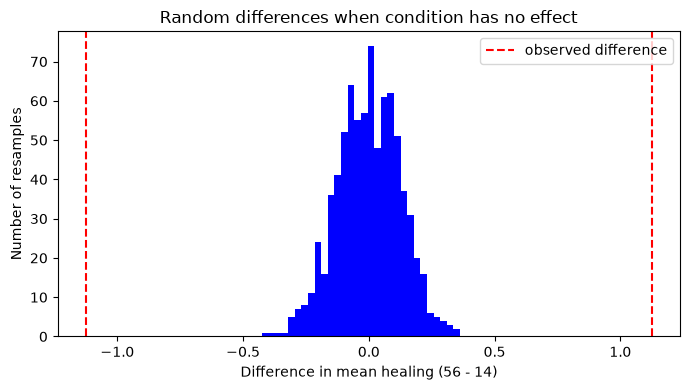

In [36]:
rng = np.random.default_rng(42) # seeded so the results are reproducible
n_resamples = 800

null_diffs = [] # one 56 - 14 difference per random resample
for i in range(n_resamples):
    fake = rng.choice(healing, size=len(healing)) # draws with replacement from all the ratings
    null_diffs.append(np.mean(fake[condition == 56]) - np.mean(fake[condition == 14]))

plt.figure(figsize=(7, 4))
plt.hist(null_diffs, bins=30, color="blue")
plt.axvline(obs_diff, color="red", linestyle="--", label="observed difference")
plt.axvline(-obs_diff, color="red", linestyle="--") # mirror image, since we count both directions
plt.xlabel("Difference in mean healing (56 - 14)")
plt.ylabel("Number of resamples")
plt.title("Random differences when condition has no effect")
plt.legend()
plt.tight_layout()
plt.show()

When condition has no effect, the random differences center near 0 and stay within about ±0.4, as the histogram shows. The observed 1.125 is far outside that range.

### Part (c)

What fraction of the random differences are at least as large, in absolute value, as the observed difference? Connect this back to the Type I error idea from Part 1

In [41]:
extreme = np.sum(np.abs(null_diffs) >= abs(obs_diff)) # resamples at least as far from 0 as the real difference
print(f"{extreme} of {n_resamples} random differences are at least as large as {abs(obs_diff):.3f} in absolute value")
print(f"fraction (extreme / n_resamples): {extreme / n_resamples:.4f}")
print(f"largest random difference in absolute value: {np.max(np.abs(null_diffs)):.3f}")

0 of 800 random differences are at least as large as 1.125 in absolute value
fraction (extreme / n_resamples): 0.0000
largest random difference in absolute value: 0.426


None of the 800 random differences were as large as the observed 1.125 (with the largest was only being 0.426), so the fraction is 0 out of 800. That means it is below 1/800, or 0.125%, but not necessarily exactly zero. This fraction is the chance of seeing a gap this big if condition truly did nothing. It connects to the Type I error rate from Question 1: if we reject whenever the fraction is below q = 0.05, then q is how often we would wrongly reject when there is no effect. Here the fraction is far below q = 0.05, so this one analysis would reject.

I would not take that at face value though. Resampling every rating separately treats the 2425 ratings as 2425 independent people, but as noted in Part 2(c) the 25 ratings of one photo are correlated and there are really only 33 participants. That makes the random differences much too tightly clustered around 0, so the fraction is smaller than it should be. Part 1 also showed that trying many analyses pushes the chance of a false rejection up to $1-(1-q)^N$, so one small fraction from one comparison is weaker evidence than it looks.

## Question 4: Reacting to a disagreement between experts

I find Gelman and Brown more persuasive and my own analysis lined up with their concerns. In Question 1, with a 5% error rate per analysis, it takes only N = 14 analyses to reach a 50% chance of at least one false rejection, which is the garden of forking paths that Gelman describes in his blog post. In Questions 2 and 3, condition and session were mixed together, people varied far more than the conditions did, and my randomization test gave 0 of 800, but it treated all 2425 ratings as independent. Gelman and Brown warn that it is easy to get strong-looking results from correlated errors in multilevel data. Their perspective gave some more insight into how I viewed the problem. The raw means looked like a clear trend, but the evidence is weaker than 0 of 800 suggests. 

Aungle et al. make fair points about the literature (Gelman and Brown reviewed only 3 of the 28 cited papers, and one survey item was a manipulation check), and I can't judge who is right without reading those studies myself and learning how to analyze multilevel data. An LLM could help by pulling up what a cited paper actually says, but in the blog comments an AI summary of the study called it "compelling evidence" and Gelman called it a terrible summary, so I would check anything it says against the source. Gelman's steps 5 and 6 say journals, universities, and the media reward weak evidence for outlandish claims, and Aungle et al. note there is little appetite for exact replications, so I don't think current incentives point the right way.

## LLM Statement

Model Used: Sonnet 5 on Claude's chat app.

For this assignment, I used Claude primarily as a formatting and comprehension aid rather than as a source of analysis or answers. In Question 1, I am not very familiar with LaTeX, so I asked Claude to help me convert and format the probability expressions and closed-form derivations — such as the independent-analyses formula in part (a) and the correlated Bernoulli model in part (c) — into properly rendered LaTeX code, since I had already worked out the math by hand and just needed help translating it into the notebook. I also used Claude to build a better intuition for covariance: I pasted the Unit 2 notes into the chat and asked it to restate the mathematical notation in simpler terms, which helped me connect the formal definitions to what I already understood conceptually, since I worked on this assignment before our Friday lecture and had only covered material through Unit 2.1 at that point. Beyond these two uses, I relied on prior experience rather than AI assistance for the coding itself; most of the numpy and DataFrame analysis techniques I used came from what I learned previously in QSS20: Modern Statistical Computing.